<a href="https://colab.research.google.com/github/ab23ms233/deep-learning/blob/main/dog_vs_cat_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Setting up the environment**

## Downloading dataset

We download the dogsvscats classifier dataset from Kaggle

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("salader/dogsvscats")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'dogsvscats' dataset.
Path to dataset files: /kaggle/input/dogsvscats


## Importing libraries

In [ ]:
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.utils import image_dataset_from_directory

from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, GlobalAveragePooling2D, Input, BatchNormalization, Dropout, RandomFlip, RandomZoom, RandomRotation

import numpy as np
import matplotlib.pyplot as plt

## Splitting dataset into training and testing

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = image_dataset_from_directory(directory=path+r'/train',
                             labels='inferred',
                             label_mode='int',
                             batch_size=BATCH_SIZE,
                             image_size=IMG_SIZE,
                             seed=SEED)

validation_ds = image_dataset_from_directory(directory=path+r'/test',
                             labels='inferred',
                             label_mode='int',
                             batch_size=BATCH_SIZE,
                             image_size=IMG_SIZE,
                             seed=SEED)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


## Visualising data from the dataset

### Class labels

In [ ]:
class_names = train_ds.class_names
class_names

['cats', 'dogs']

### Images

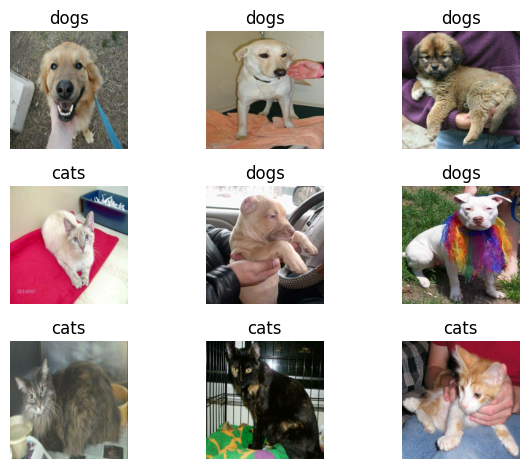

In [ ]:
for images, labels in train_ds.take(1):

    for i in range(9):
        plt.subplot(3, 3, i+1)

        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()

# **Preprocessing**

## Prefetching for faster computation

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
validation_ds = validation_ds.prefetch(buffer_size=AUTOTUNE)

## Data augmentation

We make small transformations on every image so that the neural netwrok trains on a different image in every epoch. This reduces overfitting and increases validation accuracy on new data.

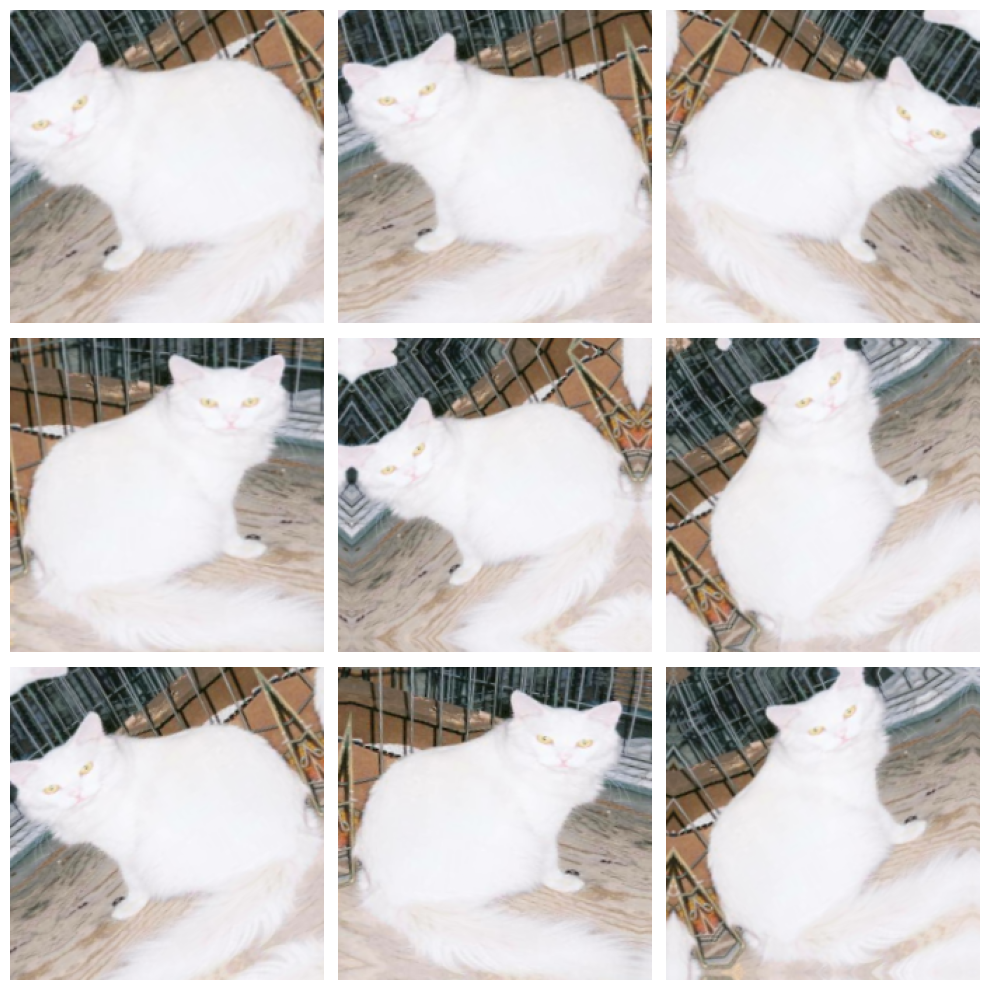

In [ ]:
data_augmentation = Sequential([RandomFlip("horizontal"),
                                RandomRotation(0.1),
                                RandomZoom(0.1)])

for image, _ in train_ds.take(1):
    image1 = image[0]
    plt.figure(figsize=(10, 10))

    for i in range(9):
        plt.subplot(3, 3, i+1)

        augmented_image = data_augmentation(tf.expand_dims(image1, 0))
        plt.imshow(augmented_image[0]/255)
        plt.axis("off")

plt.tight_layout()

## Normalisation

We normalise the pixel values from [0-1] for the 1st model, so that training is faster.

In [ ]:
def normalise(image, label):
    image = tf.cast(image/255., tf.float32)
    return (image, label)

train_ds_copy = train_ds
validation_ds_copy = validation_ds

train_ds = train_ds.map(normalise)
validation_ds = validation_ds.map(normalise)

### Verifying Dataset Equality
We will take one batch from each dataset and compare the pixel values and labels to see if they match.

In [ ]:
# Take one batch from both
for (img1, lbl1), (img2, lbl2) in zip(train_ds.take(1), train_ds_copy.take(1)):
    # Check if images are equal
    img_equal = tf.reduce_all(tf.equal(img1, img2))
    # Check if labels are equal
    lbl_equal = tf.reduce_all(tf.equal(lbl1, lbl2))

    print(f"Images match: {img_equal.numpy()}")
    print(f"Labels match: {lbl_equal.numpy()}")

    if not img_equal:
        print("\nNote: If one dataset is normalized (0-1) and the other is raw (0-255), they will not match.")
        print(f"Max value in ds1: {np.max(img1)}")
        print(f"Max value in ds2: {np.max(img2)}")

Images match: False
Labels match: False

Note: If one dataset is normalized (0-1) and the other is raw (0-255), they will not match.
Max value in ds1: 1.0
Max value in ds2: 255.0


# **MODEL 1:** Basic CNN model

## Preparing the Neural network

In [ ]:
model1 = Sequential([Input(shape=(IMG_SIZE + (3, ))),
                     data_augmentation,

                   Conv2D(16, kernel_size=(3, 3), padding='valid', activation='relu'),
                   BatchNormalization(),
                   MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'),

				   Conv2D(32, kernel_size=(3, 3), padding='valid', activation='relu'),
                    BatchNormalization(),
                   MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'),

				   Conv2D(64, kernel_size=(3, 3), padding='valid', activation='relu'),
                    BatchNormalization(),
                   MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'),

				   GlobalAveragePooling2D(),
                   Dense(128, activation='relu'),
                    BatchNormalization(),
                    Dropout(0.2),
                   Dense(64, activation='relu'),
                    BatchNormalization(),
                    Dropout(0.1),
                   Dense(1, activation='sigmoid')])

model1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,441 (161.88 KB)

 Trainable params: 40,833 (159.50 KB)

 Non-trainable params: 608 (2.38 KB)

## Traininig the NN

In [ ]:
# Early stopping
early_stopping = EarlyStopping(monitor='val_loss',
                               patience=3,
                               restore_best_weights=True)

model1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history1 = model1.fit(train_ds, epochs=10, validation_data=validation_ds, callbacks=[early_stopping])

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 80ms/step - accuracy: 0.6073 - loss: 0.6797 - val_accuracy: 0.6164 - val_loss: 0.6651
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 87ms/step - accuracy: 0.6581 - loss: 0.6173 - val_accuracy: 0.6578 - val_loss: 0.6161
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 51s 81ms/step - accuracy: 0.6917 - loss: 0.5831 - val_accuracy: 0.6972 - val_loss: 0.5646
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 51s 81ms/step - accuracy: 0.7121 - loss: 0.5563 - val_accuracy: 0.7202 - val_loss: 0.5572
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 51s 81ms/step - accuracy: 0.7279 - loss: 0.5378 - val_accuracy: 0.7082 - val_loss: 0.5804
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 51s 81ms/step - accuracy: 0.7437 - loss: 0.5185 - val_accuracy: 0.7382 - val_loss: 0.5521
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 85ms/step - accuracy: 0.7614 - loss: 0.4943 - val_accuracy: 0.7224 - val_loss: 0.6346
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 80ms/step - accuracy: 0.7814 - loss: 0.4627 - 

## Plotting

We plot loss and accuracy for the model

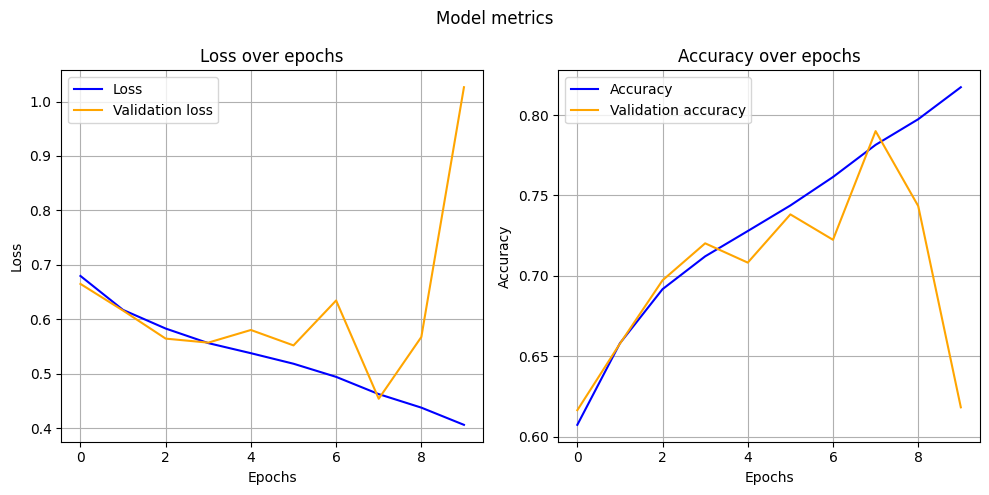

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Loss
ax[0].plot(history1.history['loss'], color='blue', label='Loss')
ax[0].plot(history1.history['val_loss'], color='orange', label='Validation loss')
ax[0].set_title("Loss over epochs")
ax[0].set_ylabel("Loss")
ax[0].set_xlabel("Epochs")
ax[0].legend()
ax[0].grid()

# Accuracy
ax[1].plot(history1.history['accuracy'], color='blue', label='Accuracy')
ax[1].plot(history1.history['val_accuracy'], color='orange', label='Validation accuracy')
ax[1].set_title("Accuracy over epochs")
ax[1].set_ylabel("Accuracy")
ax[1].set_xlabel("Epochs")
ax[1].legend()
ax[1].grid()

fig.suptitle("Model metrics")
fig.tight_layout()
plt.show()

# **MODEL 2:** Transfer learning using MobileNetV2 architecture using feature extraction

## Importing MobileNetV2 architecture

We import only the bottom convolutional base, not the top classification layer.

In [ ]:
from tensorflow.keras import applications

# Preprocessing input image
preprocess_input = applications.mobilenet_v2.preprocess_input

# Importing base model
IMG_SIZE_RGB = (224, 224, 3)
base_model = applications.MobileNetV2(input_shape=IMG_SIZE_RGB,
                                      include_top=False,
                                      weights='imagenet')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
image_batch, label_batch = next(iter(train_ds_copy))
feature_batch = base_model(image_batch)
feature_batch.shape

TensorShape([32, 7, 7, 1280])

## Base model summary

In [ ]:
base_model.trainable = False
base_model.summary()

Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

## Preparing the classification layer

We train the classification layer according to our problem

In [ ]:
globalavg_layer = GlobalAveragePooling2D()
prediction_layer = Dense(1, activation='sigmoid')

## Preparing the entire model

Model is prepared using the Keras functional API to change runtime parameters

In [ ]:
from tensorflow.keras import Model

inputs = Input(shape=IMG_SIZE_RGB)
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = globalavg_layer(x)
x = Dropout(0.2)(x)
outputs = prediction_layer(x)

model2 = Model(inputs, outputs)
model2.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Plotting the model

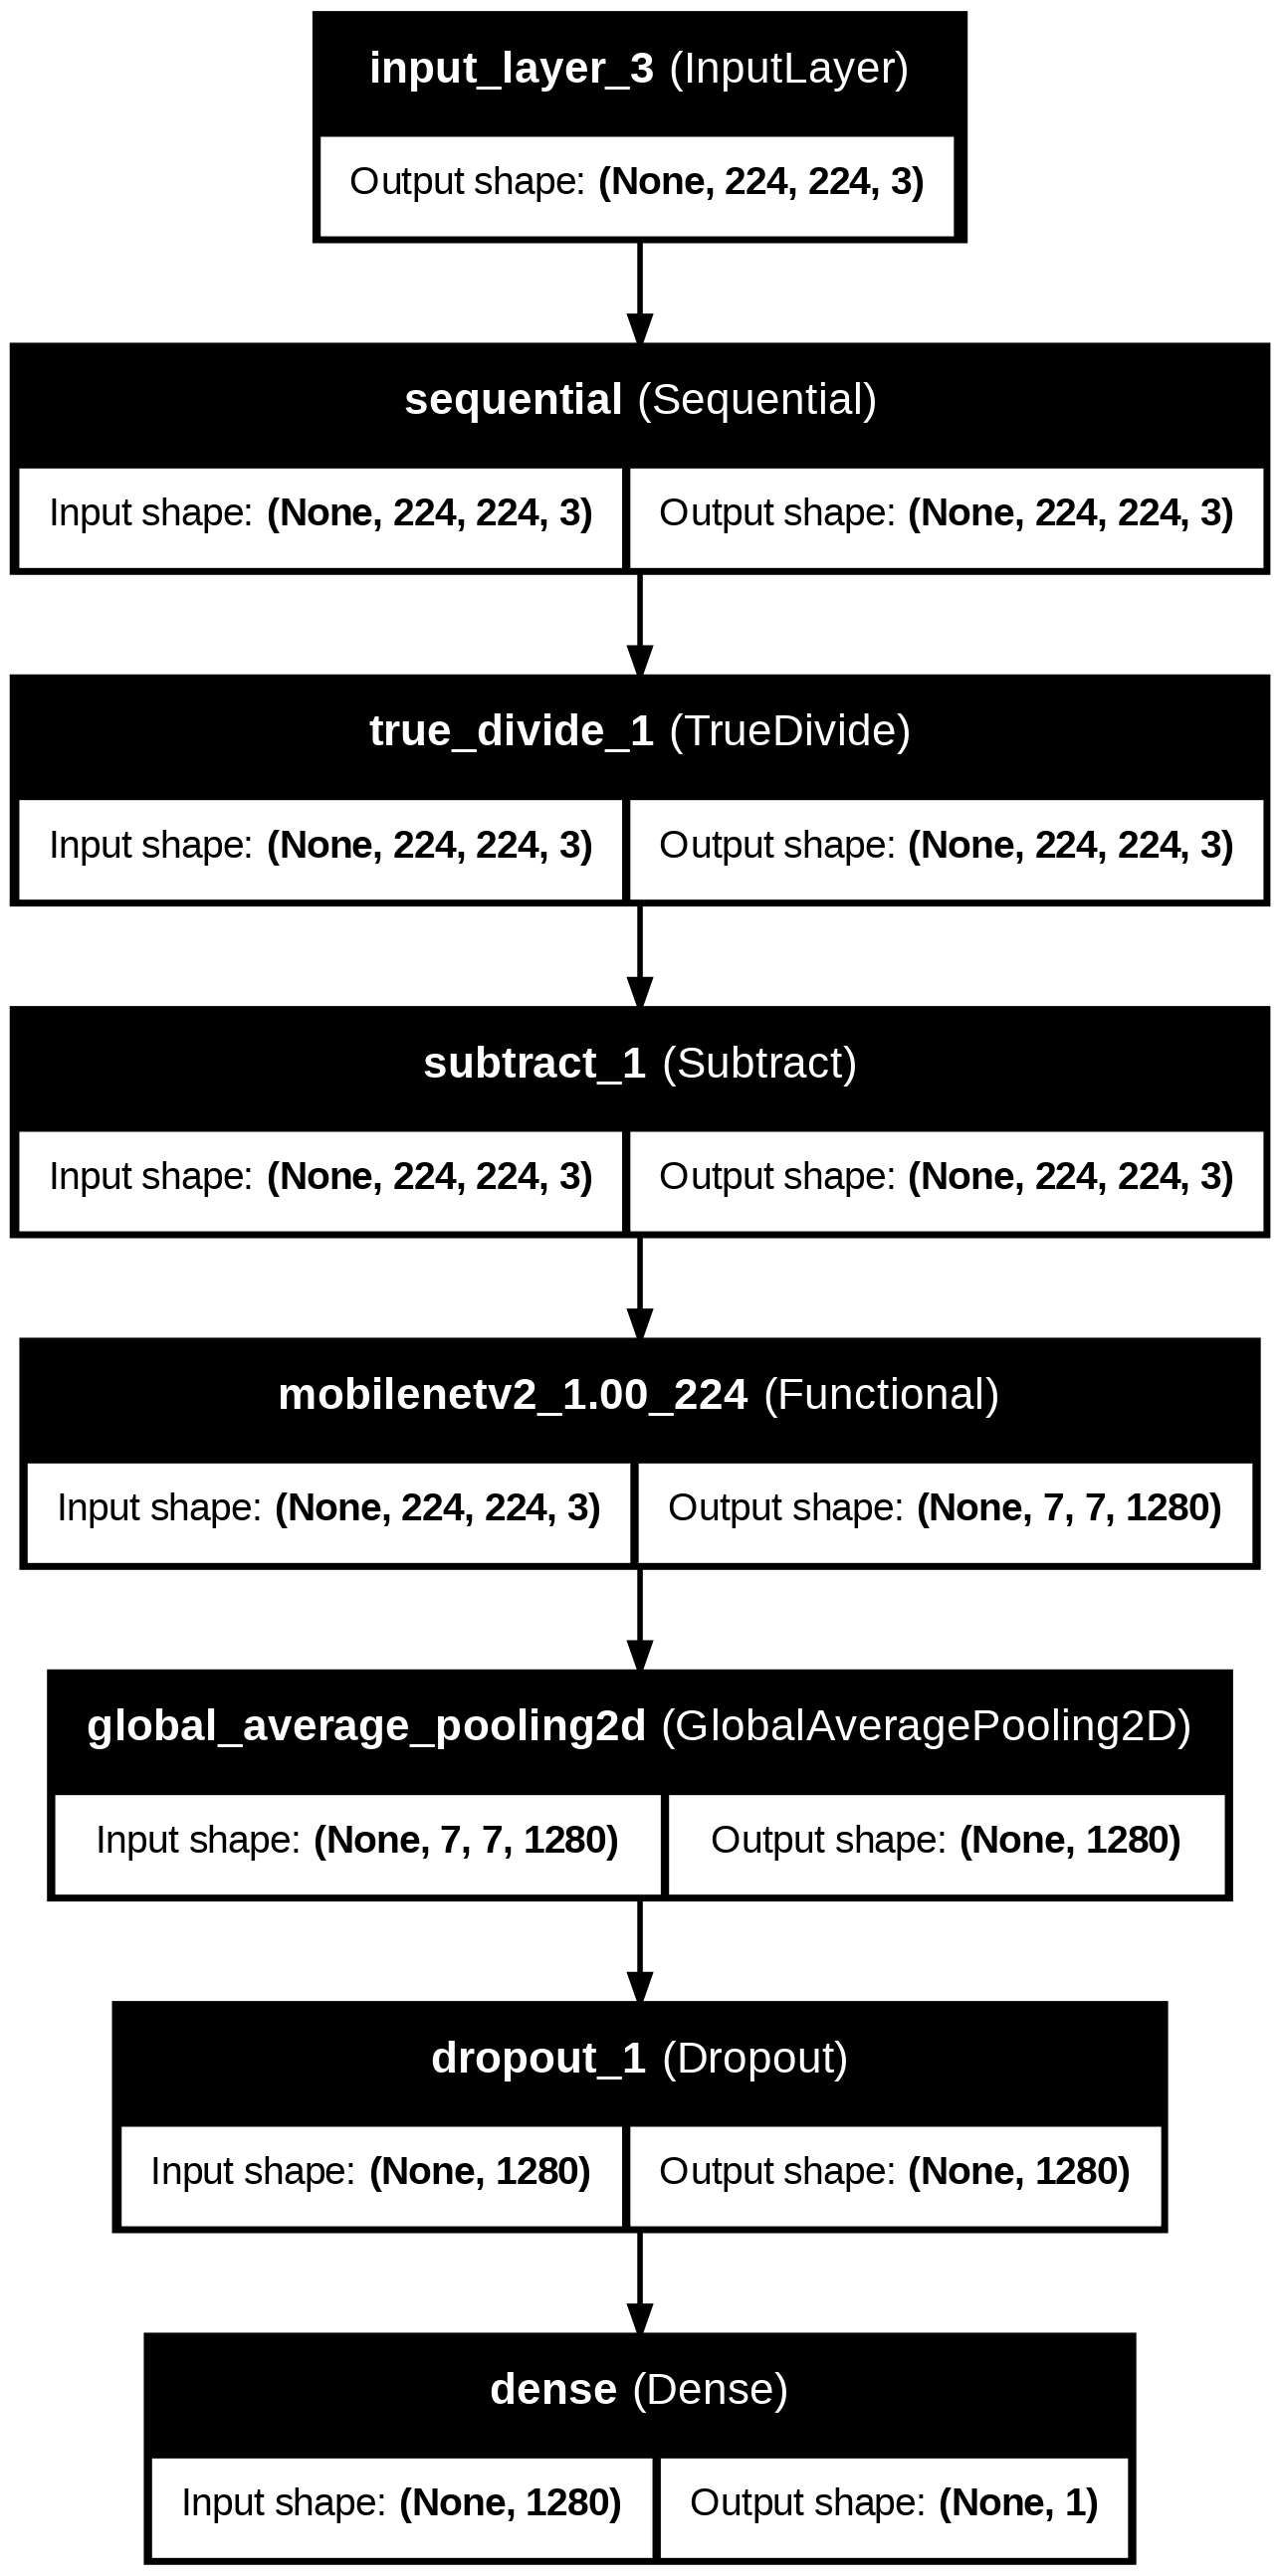

In [ ]:
from tensorflow.keras.utils import plot_model

plot_model(model2,
           show_shapes=True,
           show_layer_names=True,
           to_file='model_flowchart.png')

## Compiling the model

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Channging lr of optimiser
base_lr = 1e-4
model2.compile(optimizer=Adam(learning_rate=base_lr),
                loss='binary_crossentropy',
                metrics=['accuracy'])

history2 = model2.fit(train_ds_copy, epochs=10, validation_data=validation_ds_copy, callbacks=[early_stopping])

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 78ms/step - accuracy: 0.8831 - loss: 0.2991 - val_accuracy: 0.9736 - val_loss: 0.1188
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 78ms/step - accuracy: 0.9625 - loss: 0.1209 - val_accuracy: 0.9802 - val_loss: 0.0785
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 48s 77ms/step - accuracy: 0.9681 - loss: 0.0949 - val_accuracy: 0.9818 - val_loss: 0.0652
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 47s 75ms/step - accuracy: 0.9715 - loss: 0.0825 - val_accuracy: 0.9832 - val_loss: 0.0584
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 47s 75ms/step - accuracy: 0.9722 - loss: 0.0767 - val_accuracy: 0.9834 - val_loss: 0.0535
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 74ms/step - accuracy: 0.9755 - loss: 0.0706 - val_accuracy: 0.9834 - val_loss: 0.0502
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 74ms/step - accuracy: 0.9769 - loss: 0.0671 - val_accuracy: 0.9840 - val_loss: 0.0482
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 74ms/step - accuracy: 0.9752 - loss: 0.0653 - 

## Plotting metrics

We plot loss and accuracy

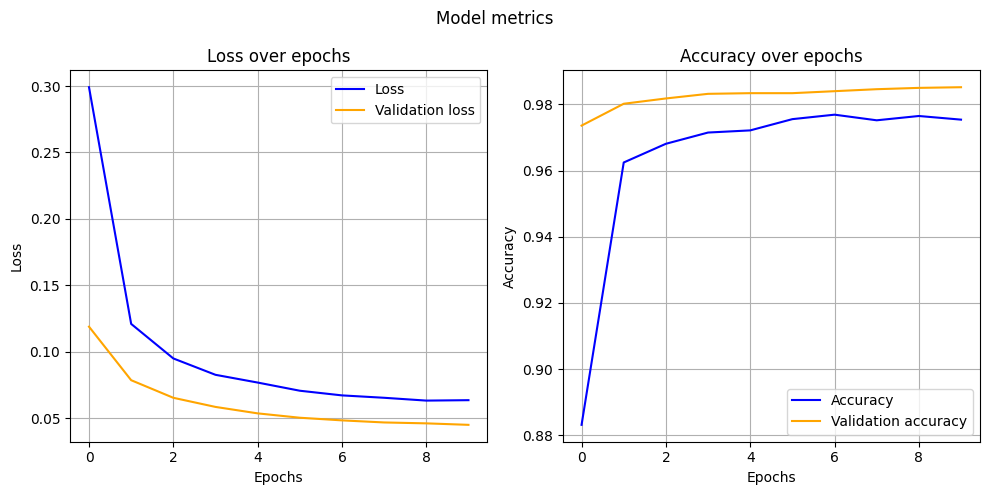

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Loss
ax[0].plot(history2.history['loss'], color='blue', label='Loss')
ax[0].plot(history2.history['val_loss'], color='orange', label='Validation loss')
ax[0].set_title("Loss over epochs")
ax[0].set_ylabel("Loss")
ax[0].set_xlabel("Epochs")
ax[0].legend()
ax[0].grid()

# Accuracy
ax[1].plot(history2.history['accuracy'], color='blue', label='Accuracy')
ax[1].plot(history2.history['val_accuracy'], color='orange', label='Validation accuracy')
ax[1].set_title("Accuracy over epochs")
ax[1].set_ylabel("Accuracy")
ax[1].set_xlabel("Epochs")
ax[1].legend()
ax[1].grid()

fig.suptitle("Model metrics")
fig.tight_layout()
plt.show()

## Saving and Loading the Model
We use `.save()` to export the entire model (architecture, weights, and optimizer state).

### Mounting Google Drive for Permanent Storage
This will prompt you for permission to access your Drive files.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Saving the model

Now we save the model to a specific folder in your Drive (e.g., the root directory of your Drive).

In [ ]:
# Save the model to Google Drive
model_path = '/content/drive/MyDrive/transfer_model.keras'
model2.save(model_path)
print(f"Model saved to Google Drive at: {model_path}")

Model saved to Google Drive at: /content/drive/MyDrive/transfer_model.keras


### Reloading the model for predictions

In [ ]:
# Define the path where the model was saved in Drive
drive_model_path = '/content/drive/MyDrive/transfer_model.keras'

# Load the model
reloaded_model = tf.keras.models.load_model(drive_model_path)

# Example: Making a prediction on a single batch from the validation set
for images, labels in validation_ds.take(1):
    predictions = reloaded_model.predict(images)
    # Convert sigmoid output to class label (0 or 1)
    predicted_labels = (predictions > 0.5).astype("int32")

    print(f"Predicted labels for first 5: {predicted_labels[:5].flatten()}")
    print(f"Actual labels for first 5: {labels[:5].numpy()}")
    break